In [1]:
!pip install roboflow ultralytics albumentations opencv-python pandas seaborn -q

from roboflow import Roboflow
rf = Roboflow(api_key="TMQeqH1Jz4eRXvAmLCOG")
project = rf.workspace("hannah-4cxv5").project("vehicle-detection-ph9yu")
version = project.version(1)
dataset = version.download("yolov8")

print(f"Dataset downloaded to: {dataset.location}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 78.9 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to Vehicle-detection-1 in yolov8:: 100%|██████████| 15922/15922 [00:02<00:00, 6418.35it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to: /content/Vehicle-detection-1


Found 5968 training images. Generating EDA plots...




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



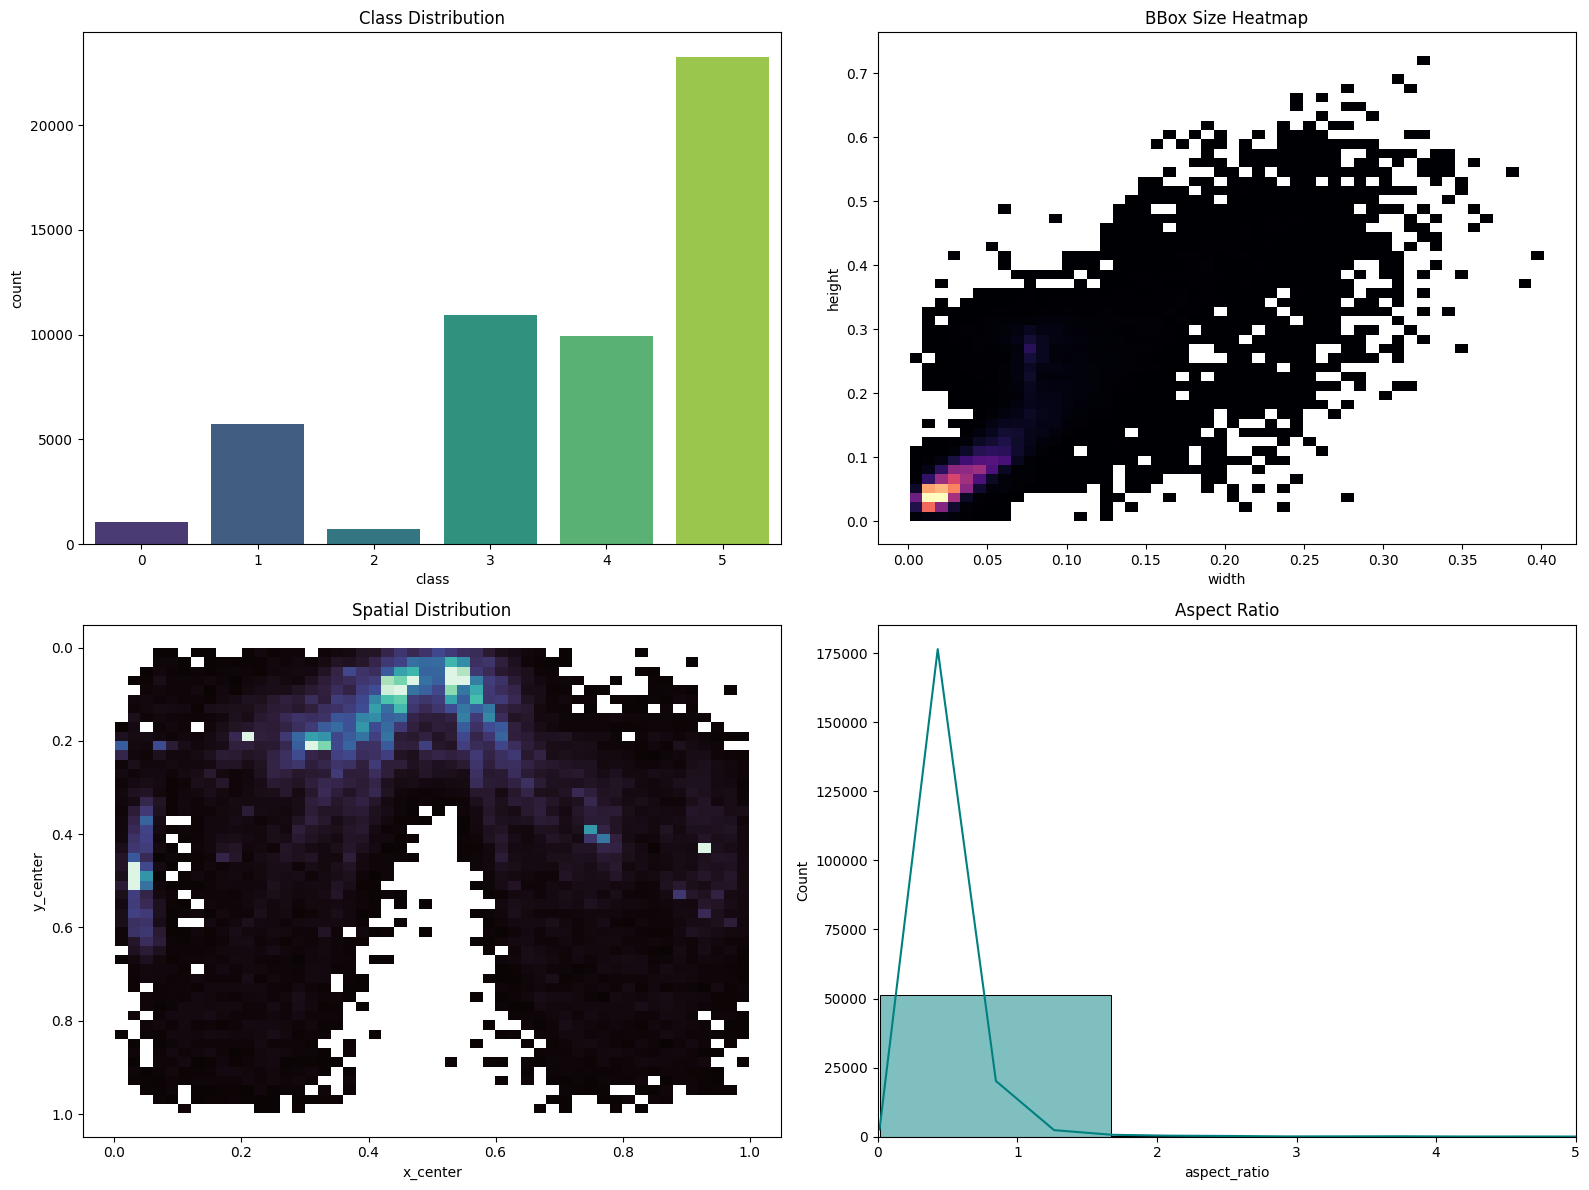

EDA Complete.


In [ ]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


base_path = dataset.location


train_images = glob.glob(os.path.join(base_path, "train", "images", "*.jpg"))
if not train_images:
    train_images = glob.glob(os.path.join(base_path, "train", "*.jpg"))

print(f"Found {len(train_images)} training images. Generating EDA plots...")


labels_data = []
for img_path in train_images:
    lbl_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    c, x, y, w, h = map(float, parts)
                    if w > 0 and h > 0:
                        labels_data.append([int(c), x, y, w, h, w*h, w/h])


df = pd.DataFrame(labels_data, columns=['class', 'x_center', 'y_center', 'width', 'height', 'area', 'aspect_ratio'])
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(data=df, x='class', ax=axs[0, 0], palette='viridis')
axs[0, 0].set_title('Class Distribution')

sns.histplot(data=df, x='width', y='height', bins=50, pmax=0.9, cmap='magma', ax=axs[0, 1])
axs[0, 1].set_title('BBox Size Heatmap')

sns.histplot(data=df, x='x_center', y='y_center', bins=50, pmax=0.9, cmap='mako', ax=axs[1, 0])
axs[1, 0].invert_yaxis()
axs[1, 0].set_title('Spatial Distribution')

sns.histplot(data=df, x='aspect_ratio', bins=50, kde=True, ax=axs[1, 1], color='teal')
axs[1, 1].set_xlim(0, 5)
axs[1, 1].set_title('Aspect Ratio')

plt.tight_layout()
plt.show()
print("EDA Complete.")

In [3]:
import cv2
import albumentations as A
from tqdm import tqdm

print(" Starting Data Augmentation...")

BBOX_PARAMS = A.BboxParams(format="yolo", label_fields=["class_labels"], min_visibility=0.3, clip=True)
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(0.3, 0.3, p=0.6),
    A.MotionBlur(blur_limit=(3, 9), p=0.25)
], bbox_params=BBOX_PARAMS)

for img_path in tqdm(train_images, desc="Augmenting"):
    lbl_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')

    img = cv2.imread(img_path)
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    bboxes, labels = [], []
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    c, x, y, w, h = map(float, parts)
                    if w > 0 and h > 0:
                        bboxes.append([x, y, w, h])
                        labels.append(int(c))

    # Create 2 augmented copies per image
    for i in range(2):
        try:
            res = train_aug(image=img, bboxes=bboxes, class_labels=labels)
            stem = os.path.splitext(os.path.basename(img_path))[0]

            new_img_path = os.path.join(os.path.dirname(img_path), f"{stem}_aug{i}.jpg")
            new_lbl_path = os.path.join(os.path.dirname(lbl_path), f"{stem}_aug{i}.txt")

            cv2.imwrite(new_img_path, cv2.cvtColor(res["image"], cv2.COLOR_RGB2BGR))

            if bboxes:
                with open(new_lbl_path, "w") as f:
                    for bb, cl in zip(res["bboxes"], res["class_labels"]):
                        f.write(f"{cl} {bb[0]:.6f} {bb[1]:.6f} {bb[2]:.6f} {bb[3]:.6f}\n")
        except: continue

print("Data augmentation is completely done!")

 Starting Data Augmentation...


Augmenting: 100%|██████████| 5968/5968 [01:05<00:00, 91.39it/s] 

Data augmentation is completely done!


#Running pretrained yolo

In [4]:
import os
import glob
from ultralytics import YOLO

yaml_files = glob.glob(os.path.join(dataset.location, "*.yaml"))
if not yaml_files:
    raise Exception("Could not find the data.yaml file")

yaml_path = yaml_files[0]
print(f"Found YAML config at: {yaml_path}")

print("Starting YOLOv8 Nano Training")
model_n = YOLO("yolov8n.pt")
model_n.train(data=yaml_path, epochs=5, imgsz=640, batch=16, project="runs", name="yolo_nano")

print("Starting YOLOv8 Small Training")
model_s = YOLO("yolov8s.pt")
model_s.train(data=yaml_path, epochs=5, imgsz=640, batch=16, project="runs", name="yolo_small")

print("Phase 2 YOLO Training Complete")

Found YAML config at: /content/Vehicle-detection-1/data.yaml
Starting YOLOv8 Nano Training
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Vehicle-detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_nano, nbs=

#Model Comparison

| Model | Parameters | Inference Speed | mAP@50 |
| :--- | :--- | :--- | :--- |
| YOLOv8 Nano | 3.0 M | 2.4 ms | 0.898 |
| YOLOv8 Small | 11.1 M | 4.8 ms | 0.929 |

**Conclusion:**
We selected the YOLOv8 Nano model for final deployment. While the Small model has slightly higher accuracy, the Nano model is twice as fast and requires significantly less computational memory. This makes the Nano model the optimal choice for maintaining real-time processing speeds on edge devices like dashcams.

#Yolo from scratch


In [7]:
import glob, os, cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

train_images = glob.glob(os.path.join(dataset.location, "train", "images", "*.jpg"))
if not train_images:
    train_images = glob.glob(os.path.join(dataset.location, "train", "*.jpg"))

class YOLO_Scratch_Dataset(Dataset):
    def __init__(self, img_paths, S=7, B=1, C=6, img_size=448):
        self.img_paths = img_paths
        self.S, self.B, self.C = S, B, C
        self.transform = T.Compose([T.ToPILImage(), T.Resize((img_size, img_size)), T.ToTensor()])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, index):
        img_path = self.img_paths[index]
        lbl_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        img = self.transform(img)
        label_matrix = torch.zeros((self.S, self.S, self.C + 5 * self.B))
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        c, x, y, w, h = map(float, parts)
                        i, j = int(self.S * y), int(self.S * x)
                        if label_matrix[i, j, self.C] == 0:
                            label_matrix[i, j, self.C] = 1.0
                            label_matrix[i, j, self.C+1:self.C+5] = torch.tensor([x * self.S - j, y * self.S - i, w * self.S, h * self.S])
                            label_matrix[i, j, int(c)] = 1.0
        return img, label_matrix

scratch_loader = DataLoader(YOLO_Scratch_Dataset(train_images[:500]), batch_size=16, shuffle=True)

class YOLOv1_Scratch(nn.Module):
    def __init__(self, S=7, B=1, C=6):
        super().__init__()
        self.S, self.B, self.C = S, B, C
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.LeakyReLU(0.1), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.1), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.1), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.1), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.1), nn.MaxPool2d(2, 2),
            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.LeakyReLU(0.1), nn.MaxPool2d(2, 2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * S * S, 512), nn.LeakyReLU(0.1),
            nn.Linear(512, S * S * (C + B * 5))
        )

    def forward(self, x):
        return self.head(self.backbone(x)).view(-1, self.S, self.S, self.C + self.B * 5)

class YoloLoss(nn.Module):
    def __init__(self, S=7, B=1, C=6):
        super(YoloLoss, self).__init__()
        self.mse = nn.MSELoss(reduction="sum")
        self.S, self.B, self.C = S, B, C
        self.lambda_coord = 5.0
        self.lambda_noobj = 0.5

    def forward(self, predictions, target):
        obj_mask = target[..., self.C] == 1
        noobj_mask = target[..., self.C] == 0

        box_loss = self.mse(predictions[..., self.C+1:self.C+5][obj_mask], target[..., self.C+1:self.C+5][obj_mask])
        obj_loss = self.mse(predictions[..., self.C][obj_mask], target[..., self.C][obj_mask])
        noobj_loss = self.mse(predictions[..., self.C][noobj_mask], target[..., self.C][noobj_mask])
        class_loss = self.mse(predictions[..., :self.C][obj_mask], target[..., :self.C][obj_mask])

        return (self.lambda_coord * box_loss) + obj_loss + (self.lambda_noobj * noobj_loss) + class_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_scratch = YOLOv1_Scratch().to(device)

optimizer = optim.Adam(model_scratch.parameters(), lr=1e-4)

criterion = YoloLoss()

print("Training PyTorch Model from Scratch")

for epoch in range(5):
    model_scratch.train()
    total_loss = 0
    for imgs, targets in scratch_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()
        predictions = model_scratch(imgs)
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/5 | Average Loss: {total_loss/len(scratch_loader):.4f}")

torch.save(model_scratch.state_dict(), "best.pth")

print("Phase 3 Complete! 'best.pth' saved.")

Training PyTorch Model from Scratch
Epoch 1/5 | Average Loss: 796.4885
Epoch 2/5 | Average Loss: 335.5086
Epoch 3/5 | Average Loss: 280.8280
Epoch 4/5 | Average Loss: 250.4393
Epoch 5/5 | Average Loss: 219.7662
Phase 3 Complete! 'best.pth' saved.


FPS Benchmark

In [10]:
!pip install onnx onnxruntime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 25.8 MB/s eta 0:00:00


In [18]:
import time
import cv2
import urllib.request
import matplotlib.pyplot as plt
import onnxruntime as ort
from ultralytics import YOLO

# Load your fully trained Nano model
best_nano = YOLO("runs/detect/runs/yolo_nano/weights/best.pt")

# Benchmark
print("Running FPS Benchmark...")
start_time = time.time()
for i in range(50):
    best_nano(train_images[i % len(train_images)], verbose=False)
fps = 50 / (time.time() - start_time)
print(f"Average Inference Speed: {fps:.2f} FPS")

Running FPS Benchmark...
Average Inference Speed: 60.36 FPS


#Image Prediction Grid


Generating 9-Image Prediction Grid...


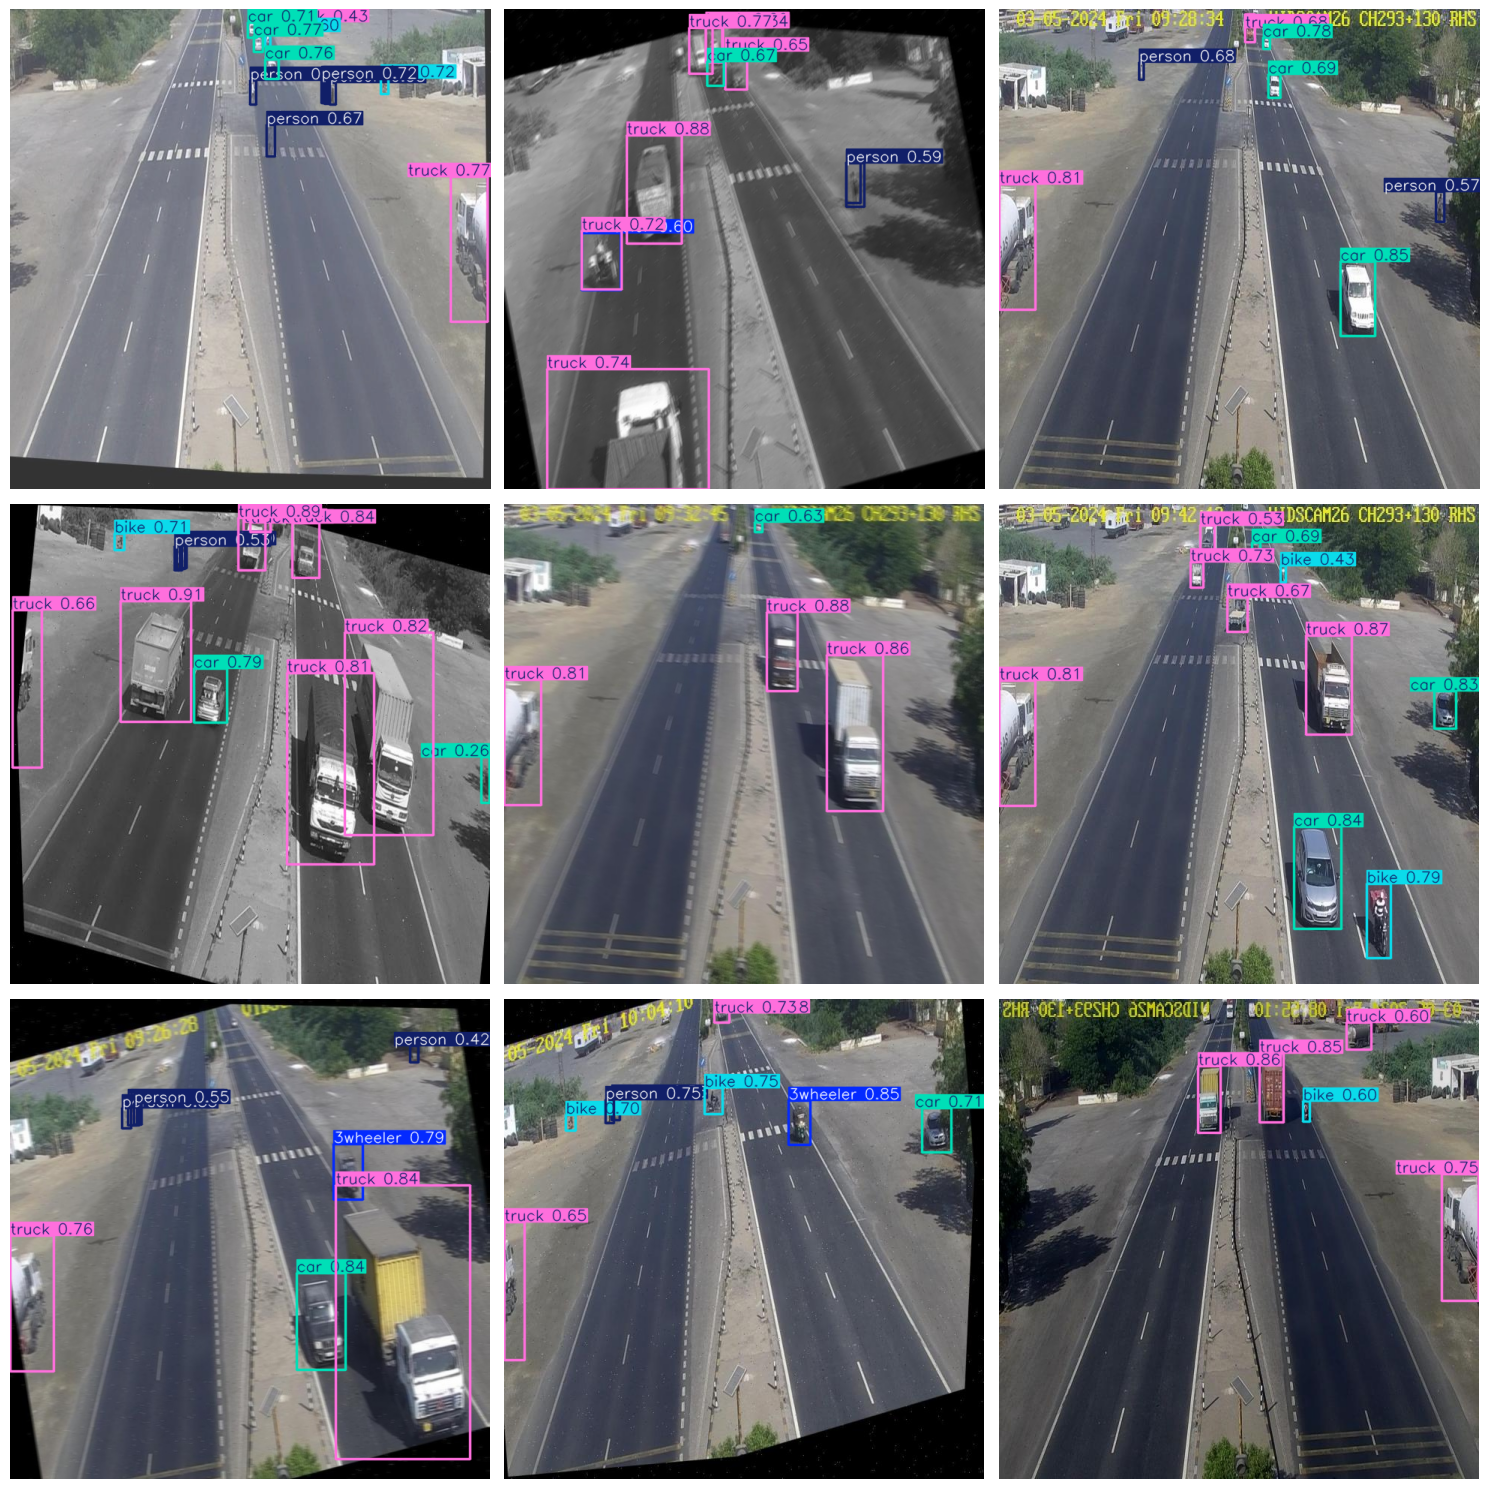

Saved predictions.png successfully.


In [12]:
print("Generating 9-Image Prediction Grid...")
results = best_nano(train_images[:9], verbose=False)

fig, axs = plt.subplots(3, 3, figsize=(15, 15))
for i, r in enumerate(results):
    axs[i//3, i%3].imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    axs[i//3, i%3].axis('off')

plt.tight_layout()
plt.savefig("predictions.png")
plt.show()

print("Saved predictions.png successfully.")

In [14]:
# ONNX Export
print("Exporting model to ONNX format...")
onnx_path = best_nano.export(format="onnx")
print(f"Exported successfully to {onnx_path}")

Exporting model to ONNX format...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from 'runs/detect/runs/yolo_nano/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (6.0 MB)

ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 1.4s, saved as 'runs/detect/runs/yolo_nano/weights/best.onnx' (11.7 MB)

Export complete (1.7s)
Results saved to /content/runs/detect/runs/yolo_nano/weights
Predict:         yolo predict task=detect model=runs/detect/runs/yolo_nano/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/runs/yolo_nano/weights/best.onnx imgsz=640 data=/content/Vehicle-detection-1/data.yaml  
Visualize:       https://netron.app
Exported successfully to runs/detect/runs/yolo_nano/weights/best.onnx


In [16]:
print("Processing Dashcam Video")

video_url = "https://github.com/intel-iot-devkit/sample-videos/raw/master/car-detection.mp4"
urllib.request.urlretrieve(video_url, "sample.mp4")

cap = cv2.VideoCapture("sample.mp4")
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps_video = int(cap.get(cv2.CAP_PROP_FPS))

out = cv2.VideoWriter("output_dashcam_detected.mp4", cv2.VideoWriter_fourcc(*'mp4v'), fps_video, (width, height))

frames_processed = 0
while cap.isOpened() and frames_processed < 150:
    ret, frame = cap.read()
    if not ret:
        break

    annotated_frame = best_nano(frame, verbose=False)[0].plot()
    out.write(annotated_frame)
    frames_processed += 1

cap.release()
out.release()

print("Video saved to output_dashcam_detected.mp4")

Processing Dashcam Video
Video saved to output_dashcam_detected.mp4
